### Importing the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Pandas = data handling library
#Used to work with tables (rows & columns) like Excel or CSV
#Provides DataFrame and Series
#Used for:
#Reading CSV / Excel files
#Cleaning data
#Filtering, grouping, aggregating

#NumPy = numerical computing library
#Used for arrays, matrices, and math operations
#Much faster than normal Python lists
#Used for:
#Mathematical calculations
#Statistical operations
#Supporting ML algorithms

#Matplotlib = basic plotting library
#Used to create graphs and charts
#Line plots, bar charts, histograms, scatter plots
#plt controls figure creation and display

#Seaborn = advanced visualization library
#Built on top of Matplotlib
#Makes better-looking, statistical graphs
#Works very well with Pandas DataFrames
#Used for:
#Heatmaps
#Boxplots
#Correlation plots

### Loading the necessary data

In [3]:
df = pd.read_csv('preprocessing.csv')

### Doing the basic inspection

In [4]:
#Run each of the following one by one and observe the outcome
df.head() #Shows the first 5 rows of the dataset

,name,city,gender,profession,age,cgpa,placed
0,moriarity,NaN,female,phd,28.0,5.94,1
1,moriarity,asgard,NaN,bachelor,50.0,8.55,0
2,holmes,NaN,female,masters,18.0,5.56,0
3,sam,NaN,male,bachelor,25.0,8.57,1
4,sam,NaN,male,bachelor,19.0,8.76,1


In [5]:
df.tail() #Shows the last 5 rows of the dataset

,name,city,gender,profession,age,cgpa,placed
1095,holmes,NaN,male,masters,26.0,8.92,1
1096,moriarity,wakanda,male,masters,19.0,9.01,0
1097,sam,asgard,male,bachelor,30.0,7.88,0
1098,dean,gotham,male,masters,28.0,NaN,1
1099,sam,asgard,NaN,masters,24.0,8.94,1


In [6]:
df.columns #Displays all column names

Index(['name', 'city', 'gender', 'profession', 'age', 'cgpa', 'placed'], dtype='str')

In [7]:
df.info() #Total number of rows, Column names, Data type of each column (int, float, object, etc.), Number of non-null values, Memory usage

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        1009 non-null   str    
 1   city        905 non-null    str    
 2   gender      994 non-null    str    
 3   profession  921 non-null    str    
 4   age         982 non-null    float64
 5   cgpa        962 non-null    float64
 6   placed      1100 non-null   int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 60.3 KB


In [8]:
df.shape #Returns the size of the DataFrame (rows, columns)

(1100, 7)

###Getting the summary statistics and unique values

In [9]:
#Run each of the following one-by-one and observe the outcome

df.describe() #Gives statistical summary of numerical columns

,age,cgpa,placed
count,982.000000,962.000000,1100.000000
mean,28.429735,7.609033,0.499091
std,9.141244,1.495991,0.500227
min,18.000000,4.010000,0.000000
25%,22.000000,7.170000,0.000000
50%,26.000000,7.925000,0.000000
75%,30.000000,8.760000,1.000000
max,50.000000,9.490000,1.000000


In [10]:
df.describe(include='object') #Gives summary of categorical (text) columns

C:\Users\chanu\AppData\Local\Temp\ipykernel_1924\216287069.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object') #Gives summary of categorical (text) columns


,name,city,gender,profession
count,1009,905,994,921
unique,8,4,2,3
top,moriarity,wakanda,male,bachelor
freq,280,391,760,517


In [11]:
df.nunique() #Returns the number of unique values per column

name            8
city            4
gender          2
profession      3
age            24
cgpa          363
placed          2
dtype: int64

In [12]:
df['city'].value_counts() #Counts how many times each city appears

city
wakanda       391
gotham        243
asgard        152
purgatory     119
Name: count, dtype: int64

In [13]:
df['gender'].value_counts()

gender
male      760
female    234
Name: count, dtype: int64

In [14]:
df['age'].value_counts()

age
28.0    68
30.0    68
25.0    65
19.0    64
27.0    63
21.0    62
24.0    59
29.0    58
26.0    58
23.0    57
22.0    56
18.0    52
20.0    52
47.0    26
43.0    25
45.0    21
41.0    19
50.0    18
44.0    18
46.0    18
49.0    16
40.0    15
48.0    12
42.0    12
Name: count, dtype: int64

### Identifying missing values


In [15]:
df.isnull() #Creates a True / False map for missing values

,name,city,gender,profession,age,cgpa,placed
0,False,True,False,False,False,False,False
1,False,False,True,False,False,False,False
2,False,True,False,False,False,False,False
3,False,True,False,False,False,False,False
4,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...
1095,False,True,False,False,False,False,False
1096,False,False,False,False,False,False,False
1097,False,False,False,False,False,False,False
1098,False,False,False,False,False,True,False


In [16]:
df.isnull().sum() #Total number of missing values per column

name           91
city          195
gender        106
profession    179
age           118
cgpa          138
placed          0
dtype: int64

In [17]:
df.isnull().mean()  #Calculates the average of missing values per column

name          0.082727
city          0.177273
gender        0.096364
profession    0.162727
age           0.107273
cgpa          0.125455
placed        0.000000
dtype: float64

In [18]:
df.isnull().mean() * 100  #Converts the proportion into a percentage

name           8.272727
city          17.727273
gender         9.636364
profession    16.272727
age           10.727273
cgpa          12.545455
placed         0.000000
dtype: float64

### Handling missing values

In [19]:
df.dropna()  #Removes entire rows that contain any missing value.
#df1 = df.dropna()
#df1.info()
#df.info()

# Fill numeric with mean/median
df['age'].fillna(df['age'].median(), inplace=True) #Finds missing values in age, Replaces them with the median age, Updates the original DataFrame
#df.info()
df['cgpa'].fillna(df['cgpa'].mean(), inplace=True) #Finds missing values in cgpa, Replaces them with the median cgpa, Updates the original DataFrame
#df.info()

# Fill categorical with mode
df['city'].fillna(df['city'].mode()[0], inplace=True)  #What's inplace = True here is Returns a new Series, df remains unchanged
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        1009 non-null   str    
 1   city        905 non-null    str    
 2   gender      994 non-null    str    
 3   profession  921 non-null    str    
 4   age         982 non-null    float64
 5   cgpa        962 non-null    float64
 6   placed      1100 non-null   int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 60.3 KB


C:\Users\chanu\AppData\Local\Temp\ipykernel_1924\3819774977.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'].fillna(df['age'].median(), inplace=True) #Finds missing values in age, Replaces them with the median age, Updates the original DataFrame
C:\Users\chanu\AppData\Local\Temp\ipykernel_1924\3819774977.py:9: ChainedAss

### Detecting outliers


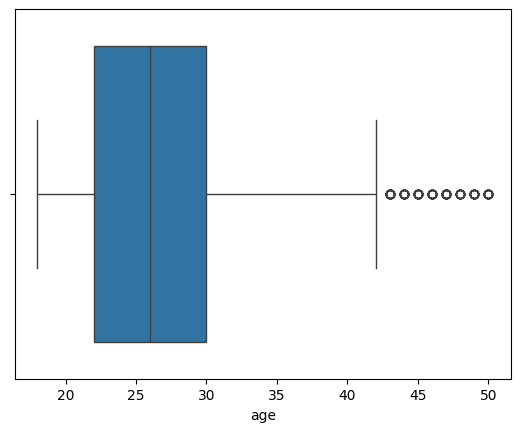

In [20]:
sns.boxplot(x=df['age']) #Creates a box plot for the age column, x= means the box is drawn horizontally
                         #Seaborn automatically: Calculates quartiles, Detects outliers
plt.show() #Displays the plot

###Using the IQR method

In [21]:
Q1 = df['age'].quantile(0.25) #The value below which 25% of the ages fall.
Q3 = df['age'].quantile(0.75) #The value below which 75% of the ages fall.
IQR = Q3 - Q1 #Measures the spread of the middle 50% of the data.

df1 = df[(df['age'] >= Q1 - 1.5*IQR) & (df['age'] <= Q3 + 1.5*IQR)] #Interpret this
                      #Keep only the rows where age lies within the normal range defined by the IQR method.
                      #Lower bound = Q1 - 1.5 × IQR
                      #Upper bound = Q3 + 1.5 × IQR
                      #Any age outside this range is considered an outlier and removed
                      #This is the standard statistical rule for detecting outliers.
                      #keeping these outliers will be needed at anomaly detections and fraud detections
df1.info()

<class 'pandas.DataFrame'>
Index: 828 entries, 0 to 1099
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        760 non-null    str    
 1   city        679 non-null    str    
 2   gender      753 non-null    str    
 3   profession  690 non-null    str    
 4   age         828 non-null    float64
 5   cgpa        730 non-null    float64
 6   placed      828 non-null    int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 51.8 KB


###Lable encoding


In [22]:
from sklearn.preprocessing import LabelEncoder #A tool from scikit-learn
                                               #Converts categorical text labels → numbers
                                               #Required because ML models only understand numbers

le = LabelEncoder()  #Creates an encoder object
                     #It will learn the mapping from text → numbers
df['gender'] = le.fit_transform(df['gender']) #Encode the gender column
                                              #fit() → finds unique categories in gender
                                              #transform() → converts them into integers
df.head()

,name,city,gender,profession,age,cgpa,placed
0,moriarity,NaN,0,phd,28.0,5.94,1
1,moriarity,asgard,2,bachelor,50.0,8.55,0
2,holmes,NaN,0,masters,18.0,5.56,0
3,sam,NaN,1,bachelor,25.0,8.57,1
4,sam,NaN,1,bachelor,19.0,8.76,1


### One-hot encoding

In [23]:
df = pd.get_dummies(df, columns=['city'], drop_first=True) #Applies One-Hot Encoding to the city column.
df.head()
#pd.get_dummies(...):-  Converts categorical text values → binary (0/1) columns
                       #Each unique city becomes its own column
#columns=['city']:- Specifies which column to encode
                   #Other columns remain unchanged
#drop_first=True:- Drops one dummy column, Prevents dummy variable trap (multicollinearity)
                  #The dropped city becomes the reference category
                  #If you had 3 cities → you get 2 new columns

,name,gender,profession,age,cgpa,placed,city_gotham,city_purgatory,city_wakanda
0,moriarity,0,phd,28.0,5.94,1,False,False,False
1,moriarity,2,bachelor,50.0,8.55,0,False,False,False
2,holmes,0,masters,18.0,5.56,0,False,False,False
3,sam,1,bachelor,25.0,8.57,1,False,False,False
4,sam,1,bachelor,19.0,8.76,1,False,False,False


###Feature scaling - Standardisation

In [24]:
from sklearn.preprocessing import StandardScaler #A tool from scikit-learn
                                                 #Used to standardize numerical features
                                                 #Transforms data to:
                                                 #Mean = 0
                                                 #Standard deviation = 1
                                                 #z=(x−μ​)/σ
                                                 #x → the original value
                                                 #(example: a student’s age = 22)
                                                 #μ → the mean (average) of all values
                                                 #(example: average age = 20)
                                                 #σ → the standard deviation
                                                 #(how spread out the values are)
                                                 #z → the standardized value (z-score)

scaler = StandardScaler()
df[['age']] = scaler.fit_transform(df[['age']])  #fit() → calculates mean & std of age
                                                 #transform() → applies standardization
                                                 #[['age']] keeps it 2D, which sklearn requires
                                                 #Scaled values replace original age values
df.head()

,name,gender,profession,age,cgpa,placed,city_gotham,city_purgatory,city_wakanda
0,moriarity,0,phd,-0.047035,5.94,1,False,False,False
1,moriarity,2,bachelor,2.360866,8.55,0,False,False,False
2,holmes,0,masters,-1.141535,5.56,0,False,False,False
3,sam,1,bachelor,-0.375385,8.57,1,False,False,False
4,sam,1,bachelor,-1.032085,8.76,1,False,False,False


###Feature scaling - min-max normalisation

In [25]:
from sklearn.preprocessing import MinMaxScaler #Rescales values to a fixed range, usually 0 to 1
                                               #x′=(x-xmin​)/(xma​x−xmin)
                                               #

scaler = MinMaxScaler()  #Initializes the scaler
df[['cgpa']] = scaler.fit_transform(df[['cgpa']]) #fit() → finds min & max CGPA
                                                  #transform() → rescales values between 0 and 1
                                                  #Original cgpa values are replaced
df.head()

,name,gender,profession,age,cgpa,placed,city_gotham,city_purgatory,city_wakanda
0,moriarity,0,phd,-0.047035,0.352190,1,False,False,False
1,moriarity,2,bachelor,2.360866,0.828467,0,False,False,False
2,holmes,0,masters,-1.141535,0.282847,0,False,False,False
3,sam,1,bachelor,-0.375385,0.832117,1,False,False,False
4,sam,1,bachelor,-1.032085,0.866788,1,False,False,False


###Detecting multi-colinearity

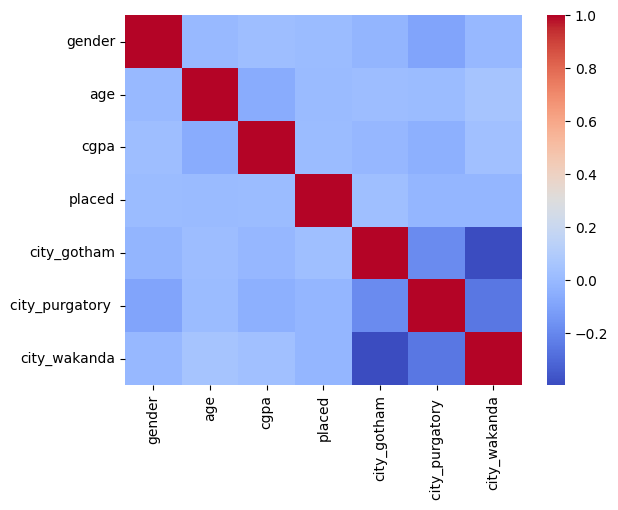

In [26]:
corr = df.corr(numeric_only=True) #Calculates pairwise correlation (Pearson by default)
                                  #Uses only numeric columns
                                  #Safely ignores:
                                  #Categorical text columns
                                  #Object-type columns
#What is correlation?
#Measures linear relationship between two variables
#Range: -1 to +1
#  Value	 Meaning
#    +1	   Strong positive
#     0	   No relationship
#    -1	   Strong negative

#corr = df.corr()                  #What will happen if this runs?
sns.heatmap(corr, cmap='coolwarm') #Visualizes correlation matrix
                                   #Colors represent strength:
                                   #🔴 red → positive correlation
                                   #🔵 blue → negative correlation
                                   #coolwarm makes contrasts clear
plt.show()

###Drop highly correlated features

In [27]:
print(df.columns)


Index(['name', 'gender', 'profession', 'age', 'cgpa', 'placed', 'city_gotham',
       'city_purgatory ', 'city_wakanda'],
      dtype='str')


In [28]:
corr = df.corr(numeric_only=True) #It calculates pairwise Pearson correlation coefficients between all numeric columns in DataFrame and prints them as a table.
print(corr)


                   gender       age      cgpa    placed  city_gotham  \
gender           1.000000  0.001871  0.022826  0.012989    -0.023071   
age              0.001871  1.000000 -0.058673  0.004266     0.015487   
cgpa             0.022826 -0.058673  1.000000  0.008259    -0.012124   
placed           0.012989  0.004266  0.008259  1.000000     0.025073   
city_gotham     -0.023071  0.015487 -0.012124  0.025073     1.000000   
city_purgatory  -0.092344  0.009334 -0.042047 -0.014001    -0.185461   
city_wakanda    -0.005247  0.051601  0.031167 -0.015743    -0.395438   

                 city_purgatory   city_wakanda  
gender                 -0.092344     -0.005247  
age                     0.009334      0.051601  
cgpa                   -0.042047      0.031167  
placed                 -0.014001     -0.015743  
city_gotham            -0.185461     -0.395438  
city_purgatory          1.000000     -0.258645  
city_wakanda           -0.258645      1.000000  


In [29]:
df.drop(columns=['highly_correlated_feature'], inplace=True)  #Replace the column name as appropriate

#Absolute correlation value	Meaning
#≥ 0.8	Highly correlated ❌
#0.5 – 0.8	Moderately correlated ⚠️
#< 0.5	Weak / acceptable ✅

KeyError: "['highly_correlated_feature'] not found in axis"

In [ ]:
# No highly correlated features found, so no columns dropped


##Exercise:
###1.How would you remove a class imbalance if available?
###2. How would you introduce a new feature?

In [ ]:
from imblearn.over_sampling import SMOTE

X = df.drop('placed', axis=1)
y = df['placed']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(y_resampled.value_counts())

Resampling (Most common & exam-friendly)

🔹 (a) Oversampling (SMOTE)

Creates synthetic samples for the minority class.

✔ Keeps all data
✔ Avoids duplication
✔ Very popular in exams & industry

In [ ]:
#Example: Age group from age
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 20, 30, 40, 100],
    labels=['Teen', 'Young', 'Adult', 'Senior']
)

Create feature from existing columns

✔ Adds meaningful information
✔ Improves model understanding

###Saving the clean dataset

In [ ]:
df.to_csv("cleaned_data.csv", index=False)